# Sensitivity Analysis — 432 Core Scenarios

Produces figures and tables for chapters 5–6 of the thesis:

- **Chapter 5 (volatility):** `t:anova_summary`, `t:ols_coefs`, `fig_spatial_cv`
- **Chapter 6 (mechanism):** `fig_merit_order_pct_bat{2,4,8}`, `fig_import_change_pct_bat{2,4,8}`, `fig_price_correlation`, `t:spillover`, `fig_eu_cv_vs_batscale`

Input data: 432 solved PyPSA scenarios stored as parquet files in `../solved_networks_core/` and `../data/tyndp2024/preprocessed/solved/`.


## Setup


In [3]:
import sys
sys.path.insert(0, "../grid-model")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import pypsa
from pathlib import Path

SOLVED_DIR    = Path("../solved_networks_core")
RESULTS_CSV   = SOLVED_DIR / "solve_results.csv"
PREPROCESSED  = Path("../data/tyndp2024/preprocessed/solved")


from plot_utils import (
    apply_thesis_style, thesis_subplots, save_fig,
    SCALE_COLORS, SCALE_MARKERS, SCALE_LABELS, CY_LABELS,
    CARRIER_COLORS, POSITIVE, NEGATIVE, NEUTRAL, REFLINE,
)
apply_thesis_style()


In [4]:
# Load all preprocessed parquets (run once — fast)
lmp_raw      = pd.read_parquet(PREPROCESSED / "lmp.parquet")
storage_p_raw = pd.read_parquet(PREPROCESSED / "storage_p.parquet")
static_su    = pd.read_parquet(PREPROCESSED / "static_storage_units.parquet")
static_gen   = pd.read_parquet(PREPROCESSED / "static_generators.parquet")

lmp_raw["timestamp"]       = pd.to_datetime(lmp_raw["timestamp"])
storage_p_raw["timestamp"] = pd.to_datetime(storage_p_raw["timestamp"])

# Battery unit names and their bus mapping
bat_units  = static_su[static_su.carrier == "battery"].index.tolist()
bat_cols   = [c for c in storage_p_raw.columns if c in bat_units]
bat_bus    = static_su.loc[bat_units, "bus"]          # Series: unit → bus

# DE00 battery units
de00_bat_cols = [c for c in bat_cols if bat_bus.get(c) == "DE00"]

# Europe-wide average LMP per (tag, timestamp)
lmp_eu_avg = (
    lmp_raw.set_index(["tag", "timestamp"])
    .mean(axis=1)
    .rename("lmp_eu_avg")
    .reset_index()
)

print(f"LMP shape:       {lmp_raw.shape}  — buses: {lmp_raw.shape[1]-2}")
print(f"Storage P shape: {storage_p_raw.shape}  — units: {storage_p_raw.shape[1]-2}")
print(f"Battery units:   {len(bat_cols)}  (DE00: {len(de00_bat_cols)})")

LMP shape:       (3784320, 57)  — buses: 55
Storage P shape: (3784320, 121)  — units: 119
Battery units:   35  (DE00: 1)


## Chapter 5 — Volatility sensitivity


### Scenario-level CV (DE00)

Build `res` with per-scenario mean/std LMP, then CV = std/mean.


In [7]:
BUS = "DE00"

lmp_raw["month"] = lmp_raw["timestamp"].dt.month
winter_mask = lmp_raw["month"].isin([12, 1, 2])
summer_mask = lmp_raw["month"].isin([6, 7, 8])

lmp_annual = lmp_raw.groupby("tag")[BUS].mean().rename("lmp_annual")
lmp_winter = lmp_raw[winter_mask].groupby("tag")[BUS].mean().rename("lmp_winter")
lmp_summer = lmp_raw[summer_mask].groupby("tag")[BUS].mean().rename("lmp_summer")

meta = pd.read_csv(RESULTS_CSV)
solved = meta[meta.status == "solved"].copy()

res = (
    solved
    .rename(columns={
        "battery_scale":    "bat_scale",
        "battery_duration": "bat_duration",
        "gas_price":        "gas_price",
        "co2_price":        "co2_price",
        "climate_year":     "climate_year",
    })
    .set_index("tag")
    .join(lmp_annual)
    .join(lmp_winter)
    .join(lmp_summer)
    .reset_index()
)

print(f"Done. LMP range: {res.lmp_annual.min():.1f} – {res.lmp_annual.max():.1f} EUR/MWh")
res.head(3)

Done. LMP range: 47.3 – 97.5 EUR/MWh


,tag,climate_year,gas_price,co2_price,bat_scale,load_scale,ntc_scale,bat_duration,nuclear_scale,battery_extendable,...,output_file,status,consistency_warnings,termination_condition,objective,slack_mwh,solve_time_s,lmp_annual,lmp_winter,lmp_summer
0,bat1x_gas18_co2_80_cy2003_dur1x,2003,18.0,80.0,1,1.0,1.0,1,1.0,False,...,/Users/radovanhodor/Documents/TUKE/Final diplo...,solved,NaN,optimal,5.091463e+10,376749.4,521.4,61.828888,109.334877,43.314304
1,bat1x_gas18_co2_80_cy2003_dur2x,2003,18.0,80.0,1,1.0,1.0,2,1.0,False,...,/Users/radovanhodor/Documents/TUKE/Final diplo...,solved,NaN,optimal,5.012831e+10,316227.5,530.8,61.218777,106.083801,43.930775
2,bat1x_gas18_co2_80_cy2003_dur3x,2003,18.0,80.0,1,1.0,1.0,3,1.0,False,...,/Users/radovanhodor/Documents/TUKE/Final diplo...,solved,NaN,optimal,4.976269e+10,295134.7,535.9,61.402092,106.082443,44.475574


In [4]:
# CV per scenario for DE00 (used by ANOVA and subsequent analysis)
lmp_std_s2 = lmp_raw.groupby("tag")[BUS].std().rename("lmp_std_s2")
lmp_mean_s2 = lmp_raw.groupby("tag")[BUS].mean().rename("lmp_mean_s2")
lmp_cv_s2 = (lmp_std_s2 / lmp_mean_s2).rename("lmp_cv_s2")

res = res.drop(columns=["lmp_cv_s2", "lmp_std_s2", "lmp_mean_s2"], errors="ignore")
res = res.set_index("tag").join(lmp_cv_s2).reset_index()

print(f"DE00 CV range: {res.lmp_cv_s2.min():.3f} – {res.lmp_cv_s2.max():.3f}")


DE00 CV range: 0.444 – 3.656


### Factorial ANOVA → table `t:anova_summary`

Decomposes CV variance across 5 parameters + all 2-way interactions. ANOVA EU cell also defines `eu_weighted_cv` used by the OLS EU cell below.


In [5]:
# Factorial ANOVA (Type II) — DE00 CV. Produces t:anova_summary (DE00 column).
import statsmodels.api as sm
from statsmodels.formula.api import ols as sm_ols

anova_data_de = res[["tag", "bat_scale", "bat_duration", "gas_price", "co2_price",
                     "climate_year", "lmp_cv_s2"]].copy()
anova_data_de.columns = ["tag", "bat_scale", "bat_duration", "gas_price",
                         "co2_price", "climate_year", "lmp_cv"]
for col in ["bat_scale", "bat_duration", "gas_price", "co2_price", "climate_year"]:
    anova_data_de[col] = anova_data_de[col].astype(str)

formula = ("lmp_cv ~ C(bat_scale) + C(bat_duration) + C(gas_price) + C(co2_price) + C(climate_year)"
           " + C(bat_scale):C(bat_duration) + C(bat_scale):C(gas_price) + C(bat_scale):C(co2_price) + C(bat_scale):C(climate_year)"
           " + C(bat_duration):C(gas_price) + C(bat_duration):C(co2_price) + C(bat_duration):C(climate_year)"
           " + C(gas_price):C(co2_price) + C(gas_price):C(climate_year) + C(co2_price):C(climate_year)")

model_de = sm_ols(formula, data=anova_data_de).fit()
table_de = sm.stats.anova_lm(model_de, typ=2)
ss_total_de = table_de["sum_sq"].sum()
table_de["eta_sq_pct"] = table_de["sum_sq"] / ss_total_de * 100

print("Factorial ANOVA (Type II) — DE00 CV")
print("=" * 80)
for idx, row in table_de.iterrows():
    name = idx.replace("C(", "").replace(")", "").replace(":", " x ")
    if idx == "Residual":
        print(f"{'Residual':<45} eta2={row['eta_sq_pct']:5.1f}%")
    else:
        sig = "***" if row["PR(>F)"] < 0.001 else "**" if row["PR(>F)"] < 0.01 else "*" if row["PR(>F)"] < 0.05 else "ns"
        print(f"{name:<45} F={row['F']:8.1f}  p={row['PR(>F)']:.4f} {sig}  eta2={row['eta_sq_pct']:5.1f}%")
print(f"\nModel explains {100 - table_de.loc['Residual', 'eta_sq_pct']:.1f}% of variance")


Factorial ANOVA (Type II) — DE00 CV
bat_scale                                     F=   550.8  p=0.0000 ***  eta2= 15.1%
bat_duration                                  F=   112.8  p=0.0000 ***  eta2=  3.1%
gas_price                                     F=   356.2  p=0.0000 ***  eta2=  6.5%
co2_price                                     F=   181.3  p=0.0000 ***  eta2=  3.3%
climate_year                                  F=  3165.8  p=0.0000 ***  eta2= 57.7%
bat_scale x bat_duration                      F=    16.9  p=0.0000 ***  eta2=  1.4%
bat_scale x gas_price                         F=     3.0  p=0.0069 **  eta2=  0.2%
bat_scale x co2_price                         F=     1.6  p=0.1335 ns  eta2=  0.1%
bat_scale x climate_year                      F=   122.2  p=0.0000 ***  eta2=  6.7%
bat_duration x gas_price                      F=     0.6  p=0.7210 ns  eta2=  0.0%
bat_duration x co2_price                      F=     0.3  p=0.9155 ns  eta2=  0.0%
bat_duration x climate_year                 

In [6]:
# Factorial ANOVA (Type II) — EU demand-weighted CV. Produces t:anova_summary (EU column).
# Also defines eu_weighted_cv used later by the OLS EU cell.
import statsmodels.api as sm
from statsmodels.formula.api import ols as sm_ols

# CV per zone per scenario
bus_cols_anova = [c for c in lmp_raw.columns if c not in ["tag", "timestamp", "month"]]
cv_per_zone = lmp_raw.groupby("tag")[bus_cols_anova].agg(["std", "mean"])
cv_vals = cv_per_zone.xs("std", axis=1, level=1) / cv_per_zone.xs("mean", axis=1, level=1)

# Demand weights from first solved scenario network
_net = pypsa.Network(str(list(SOLVED_DIR.glob("bat1x_gas22.68_co2_113.4_cy2009_dur1x.nc"))[0]))
demand_per_zone = _net.loads_t.p_set.mean()
demand_by_bus = {}
for load_id, load in _net.loads.iterrows():
    bus = load["bus"]
    if bus in bus_cols_anova:
        demand_by_bus[bus] = demand_by_bus.get(bus, 0) + demand_per_zone.get(load_id, 0)
del _net

weights = pd.Series(demand_by_bus).reindex(bus_cols_anova).fillna(0)
weights = weights / weights.sum()

eu_weighted_cv = (cv_vals * weights).sum(axis=1).rename("lmp_cv")

# Merge with scenario params
anova_data = (res[["tag", "bat_scale", "bat_duration", "gas_price", "co2_price", "climate_year"]]
              .set_index("tag").join(eu_weighted_cv).reset_index())

for col in ["bat_scale", "bat_duration", "gas_price", "co2_price", "climate_year"]:
    anova_data[col] = anova_data[col].astype(str)

formula = ("lmp_cv ~ C(bat_scale) + C(bat_duration) + C(gas_price) + C(co2_price) + C(climate_year)"
           " + C(bat_scale):C(bat_duration) + C(bat_scale):C(gas_price) + C(bat_scale):C(co2_price) + C(bat_scale):C(climate_year)"
           " + C(bat_duration):C(gas_price) + C(bat_duration):C(co2_price) + C(bat_duration):C(climate_year)"
           " + C(gas_price):C(co2_price) + C(gas_price):C(climate_year) + C(co2_price):C(climate_year)")

model_anova = sm_ols(formula, data=anova_data).fit()
anova_table = sm.stats.anova_lm(model_anova, typ=2)
ss_total = anova_table["sum_sq"].sum()
anova_table["eta_sq_pct"] = anova_table["sum_sq"] / ss_total * 100

print(f"EU demand-weighted CV range: {anova_data.lmp_cv.min():.3f} - {anova_data.lmp_cv.max():.3f}")
print("\nFactorial ANOVA (Type II) — EU demand-weighted CV")
print("=" * 80)
for idx, row in anova_table.iterrows():
    name = idx.replace("C(", "").replace(")", "").replace(":", " x ")
    if idx == "Residual":
        print(f"{'Residual':<45} eta2={row['eta_sq_pct']:5.1f}%")
    else:
        sig = "***" if row["PR(>F)"] < 0.001 else "**" if row["PR(>F)"] < 0.01 else "*" if row["PR(>F)"] < 0.05 else "ns"
        print(f"{name:<45} F={row['F']:8.1f}  p={row['PR(>F)']:.4f} {sig}  eta2={row['eta_sq_pct']:5.1f}%")
print(f"\nModel explains {100 - anova_table.loc['Residual', 'eta_sq_pct']:.1f}% of variance")


INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'TYNDP2024_Electricity_2030' has buses, carriers, generators, links, loads, storage_units, sub_networks


EU demand-weighted CV range: 0.378 - 1.707

Factorial ANOVA (Type II) — EU demand-weighted CV
bat_scale                                     F=  1307.3  p=0.0000 ***  eta2= 25.5%
bat_duration                                  F=   234.2  p=0.0000 ***  eta2=  4.6%
gas_price                                     F=   146.4  p=0.0000 ***  eta2=  1.9%
co2_price                                     F=    58.0  p=0.0000 ***  eta2=  0.8%
climate_year                                  F=  3818.2  p=0.0000 ***  eta2= 49.7%
bat_scale x bat_duration                      F=     8.4  p=0.0000 ***  eta2=  0.5%
bat_scale x gas_price                         F=     8.6  p=0.0000 ***  eta2=  0.3%
bat_scale x co2_price                         F=     4.2  p=0.0005 ***  eta2=  0.2%
bat_scale x climate_year                      F=   281.9  p=0.0000 ***  eta2= 11.0%
bat_duration x gas_price                      F=     1.3  p=0.2370 ns  eta2=  0.1%
bat_duration x co2_price                      F=     0.6  p=0.7015 

### Extended volatility metrics

`res_vol` adds std, CV, spike_hours (>150 EUR/MWh), zero_hours (<1 EUR/MWh) per scenario.


In [8]:
BUS_VOL = "DE00"

lmp_bus = lmp_raw[["tag", BUS_VOL]].copy()

lmp_std   = lmp_bus.groupby("tag")[BUS_VOL].std().rename("lmp_std")
lmp_mean_ = lmp_bus.groupby("tag")[BUS_VOL].mean().rename("_mean")
lmp_cv    = (lmp_std / lmp_mean_).rename("lmp_cv")
spike_h   = lmp_bus.groupby("tag")[BUS_VOL].apply(lambda x: int((x > 150).sum())).rename("spike_hours")
zero_h    = lmp_bus.groupby("tag")[BUS_VOL].apply(lambda x: int((x < 1).sum())).rename("zero_hours")

# Drop lmp_cv if already exists from ANOVA cell
res_clean = res.drop(columns=["lmp_cv", "lmp_std"], errors="ignore")

res_vol = (
    res_clean.set_index("tag")
    .join(lmp_std).join(lmp_cv).join(spike_h).join(zero_h)
    .reset_index()
)

print(f"Volatility metrics added. CV range: {res_vol.lmp_cv.min():.3f} – {res_vol.lmp_cv.max():.3f}")
print(f"Spike hours range:   {res_vol.spike_hours.min()} – {res_vol.spike_hours.max()} h/yr")
print(f"Near-zero hours:     {res_vol.zero_hours.min()} – {res_vol.zero_hours.max()} h/yr")
res_vol[["tag","bat_scale","bat_duration","gas_price","co2_price","climate_year",
         "lmp_annual","lmp_std","lmp_cv","spike_hours","zero_hours"]].head(3)


Volatility metrics added. CV range: 0.444 – 3.656
Spike hours range:   0 – 242 h/yr
Near-zero hours:     270 – 426 h/yr


,tag,bat_scale,bat_duration,gas_price,co2_price,climate_year,lmp_annual,lmp_std,lmp_cv,spike_hours,zero_hours
0,bat1x_gas18_co2_80_cy2003_dur1x,1,1,18.0,80.0,2003,61.828888,192.774734,3.117875,75,422
1,bat1x_gas18_co2_80_cy2003_dur2x,1,2,18.0,80.0,2003,61.218777,187.513443,3.063005,46,355
2,bat1x_gas18_co2_80_cy2003_dur3x,1,3,18.0,80.0,2003,61.402092,187.197937,3.048723,44,335


### Spatial CV → `fig_spatial_cv`

CV per bidding zone at each `bat_scale`. 15 most volatile zones are labeled, others plotted as small dots.


In [10]:
# List of bus (zone) columns from LMP data. Used by the spatial CV figure cell below.
bus_cols_lmp = [c for c in lmp_raw.columns if c not in ["tag", "timestamp", "month"]]
print(f"{len(bus_cols_lmp)} bidding zones: {bus_cols_lmp[:5]} ...")


55 bidding zones: ['AL00', 'AT00', 'BA00', 'BE00', 'BG00'] ...


Saved /Users/radovanhodor/Documents/TUKE/Final diplomova praca/tukedip_pdflatex_utf-8/figures/fig_spatial_cv.jpg


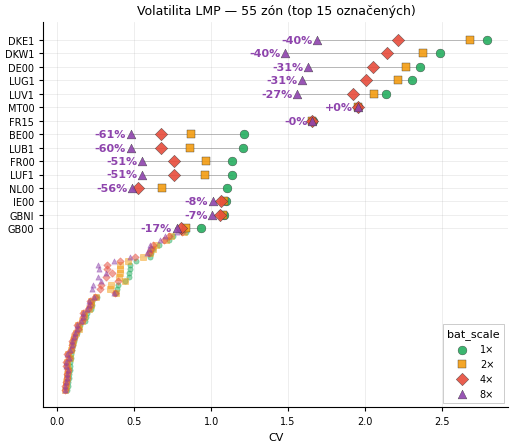

In [9]:
# Spatial volatility: CV per bus at each bat_scale (avg over all other params)

cv_by_scale = {}
for bs in [1, 2, 4, 8]:
    tags_bs = res_vol[res_vol.bat_scale == bs]['tag'].tolist()
    cv_bs = lmp_raw[lmp_raw.tag.isin(tags_bs)].groupby('tag')[bus_cols_lmp].std().mean(axis=0) / \
            lmp_raw[lmp_raw.tag.isin(tags_bs)].groupby('tag')[bus_cols_lmp].mean().mean(axis=0)
    cv_by_scale[bs] = cv_bs

cv_reduction_abs = cv_by_scale[1] - cv_by_scale[8]
zone_order = cv_by_scale[1].sort_values(ascending=True).index
top15 = set(cv_by_scale[1].nlargest(15).index)
other_zones = [z for z in zone_order if z not in top15]
top15_zones = [z for z in zone_order if z in top15]

# Packed y layout: compressed for non-top15, spaced for top15
y_map = {}
y = 0
spacing_other = 0.15
spacing_top = 0.5
for zone in zone_order:
    y_map[zone] = y
    y += spacing_top if zone in top15 else spacing_other

fig, ax = thesis_subplots('stacked_3')

# Non-top15: small, dim
for bs in [1, 2, 4, 8]:
    vals = cv_by_scale[bs].loc[other_zones]
    y_pos = [y_map[z] for z in vals.index]
    ax.scatter(vals.values, y_pos,
               color=SCALE_COLORS[bs], marker=SCALE_MARKERS[bs],
               s=14, alpha=0.5, zorder=2)

# Top15: large with labels
for bs in [1, 2, 4, 8]:
    vals = cv_by_scale[bs].loc[top15_zones]
    y_pos = [y_map[z] for z in vals.index]
    ax.scatter(vals.values, y_pos,
               color=SCALE_COLORS[bs], marker=SCALE_MARKERS[bs],
               s=40, alpha=0.9, label=SCALE_LABELS[bs],
               zorder=3, edgecolors='#333', linewidth=0.3)

# Connecting lines
for zone in zone_order:
    x_vals = [cv_by_scale[bs].loc[zone] for bs in [1, 2, 4, 8]]
    lw = 0.7 if zone in top15 else 0.3
    alpha = 0.5 if zone in top15 else 0.25
    ax.plot(x_vals, [y_map[zone]] * 4, color='gray', lw=lw, alpha=alpha, zorder=1)

# Only top15 on y-axis
ax.set_yticks([y_map[z] for z in top15_zones])
ax.set_yticklabels(list(top15_zones))

# Reduction % label at bat8x position
for zone in top15:
    cv1 = cv_by_scale[1].loc[zone]
    cv8 = cv_by_scale[8].loc[zone]
    red = (cv8 - cv1) / cv1 * 100
    ax.text(cv8 - 0.03, y_map[zone], f'{red:+.0f}%',
            va='center', ha='right', fontsize=8,
            color=SCALE_COLORS[8], fontweight='bold')

ax.set_xlabel('CV')
ax.set_title('Volatilita LMP \u2014 55 zón (top 15 označených)')
ax.legend(loc='lower right', title='bat_scale')
ax.grid(axis='x', alpha=0.3)

save_fig(fig, 'spatial_cv')
plt.show()


### OLS regression → table `t:ols_coefs`

Same specification for DE00 and EU demand-weighted CV: log2(bat_scale) + CY dummies + interaction terms. HC3 robust SE.


In [10]:
# OLS — DE00 CV (log2 bat_scale + CY dummies + interactions). Produces t:ols_coefs (DE00 column).
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

ols_data = res_vol[["bat_scale", "bat_duration", "gas_price", "co2_price",
                    "climate_year", "lmp_cv"]].copy()
ols_data["log2_bat_scale"] = np.log2(ols_data["bat_scale"])
ols_data["cy_2003"] = (ols_data["climate_year"] == 2003).astype(int)
ols_data["cy_2012"] = (ols_data["climate_year"] == 2012).astype(int)
ols_data["bat_x_cy2003"] = ols_data["log2_bat_scale"] * ols_data["cy_2003"]
ols_data["bat_x_cy2012"] = ols_data["log2_bat_scale"] * ols_data["cy_2012"]

feature_cols = ["log2_bat_scale", "bat_duration", "gas_price", "co2_price",
                "cy_2003", "cy_2012", "bat_x_cy2003", "bat_x_cy2012"]

X = sm.add_constant(ols_data[feature_cols].astype(float))
y = ols_data["lmp_cv"].astype(float)

model_de = sm.OLS(y, X).fit(cov_type="HC3")
print(model_de.summary())

print("\n=== VIF (multicollinearity check) ===")
for i_col, col in enumerate(X.columns):
    if col == "const": continue
    vif = variance_inflation_factor(X.values, i_col)
    flag = " !!!" if vif > 10 else ""
    print(f"  {col:<20} VIF = {vif:.2f}{flag}")


                            OLS Regression Results                            
Dep. Variable:                 lmp_cv   R-squared:                       0.900
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     612.2
Date:                Sun, 19 Apr 2026   Prob (F-statistic):          3.39e-227
Time:                        18:50:55   Log-Likelihood:                 14.125
No. Observations:                 432   AIC:                            -10.25
Df Residuals:                     423   BIC:                             26.37
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.1738      0.072     44.

In [11]:
# OLS — EU demand-weighted CV (same spec as DE00). Produces t:ols_coefs (EU column).
# Requires eu_weighted_cv from the ANOVA EU cell above.
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

ols_eu = (res[["tag", "bat_scale", "bat_duration", "gas_price", "co2_price", "climate_year"]]
          .set_index("tag").join(eu_weighted_cv).reset_index())
ols_eu["log2_bat_scale"] = np.log2(ols_eu["bat_scale"])
ols_eu["cy_2003"] = (ols_eu["climate_year"] == 2003).astype(int)
ols_eu["cy_2012"] = (ols_eu["climate_year"] == 2012).astype(int)
ols_eu["bat_x_cy2003"] = ols_eu["log2_bat_scale"] * ols_eu["cy_2003"]
ols_eu["bat_x_cy2012"] = ols_eu["log2_bat_scale"] * ols_eu["cy_2012"]

feature_cols_eu = ["log2_bat_scale", "bat_duration", "gas_price", "co2_price",
                   "cy_2003", "cy_2012", "bat_x_cy2003", "bat_x_cy2012"]

X_eu = sm.add_constant(ols_eu[feature_cols_eu].astype(float))
y_eu = ols_eu["lmp_cv"].astype(float)

model_eu = sm.OLS(y_eu, X_eu).fit(cov_type="HC3")
print(model_eu.summary())

print("\n=== VIF ===")
for i_col, col in enumerate(X_eu.columns):
    if col == "const": continue
    vif = variance_inflation_factor(X_eu.values, i_col)
    flag = " !!!" if vif > 10 else ""
    print(f"  {col:<20} VIF = {vif:.2f}{flag}")


                            OLS Regression Results                            
Dep. Variable:                 lmp_cv   R-squared:                       0.923
Model:                            OLS   Adj. R-squared:                  0.922
Method:                 Least Squares   F-statistic:                     368.4
Date:                Sun, 19 Apr 2026   Prob (F-statistic):          2.54e-185
Time:                        18:50:55   Log-Likelihood:                 575.48
No. Observations:                 432   AIC:                            -1133.
Df Residuals:                     423   BIC:                            -1096.
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              1.0565      0.023     45.

## Chapter 6 — Mechanism of battery impact


### Merit order displacement → `fig_merit_order_pct_bat{2,4,8}`

Per-zone annual generation change by carrier between `bat1×` baseline and higher `bat_scale` levels.


In [12]:
import re

# Load gen_p (large parquet) - one-time load
gp = pd.read_parquet(PREPROCESSED / "gen_p.parquet")
gp['bat_scale'] = gp['tag'].str.extract(r'bat(\d+)x')[0].astype(int)
gen_cols_gp = [c for c in gp.columns if re.match(r'^[A-Z]{2,4}\d{1,2}-', c)]

def carrier_group(carrier):
    if carrier.startswith('slack') or carrier.startswith('dsr'):
        return None
    if 'onwind' in carrier: return 'onwind'
    if 'offwind' in carrier: return 'offwind'
    if 'solar' in carrier: return 'solar'
    if 'nuclear' in carrier: return 'nuclear'
    if 'hydro' in carrier: return 'hydro'
    if 'lignite' in carrier: return 'lignite'
    if 'coal' in carrier: return 'coal'
    if 'gas' in carrier: return 'gas'
    if 'oil' in carrier: return 'oil'
    if 'h2' in carrier: return 'hydrogen'
    return 'other'

gen_info = {}
for c in gen_cols_gp:
    m = re.match(r'^([A-Z]{2,4}\d{1,2})-(.*)', c)
    if m:
        zone, carrier = m.group(1), m.group(2)
        cg = carrier_group(carrier)
        if cg:
            gen_info[c] = (zone, cg)

valid_cols = list(gen_info.keys())

# Vectorised aggregation: annual TWh per tag, averaged per bat_scale
annual_per_tag = gp.groupby('tag')[valid_cols].sum().div(1e6)
tag_scale = gp.drop_duplicates('tag').set_index('tag')['bat_scale']
annual_per_tag['bat_scale'] = tag_scale

# Mean annual generation per bat_scale (averaged across gas/co2/cy/duration)
by_scale = annual_per_tag.groupby('bat_scale')[valid_cols].mean()

# Melt into long dataframe
df_mo_long = by_scale.reset_index().melt(id_vars='bat_scale', var_name='col', value_name='twh')
df_mo_long['zone']    = df_mo_long['col'].map(lambda c: gen_info[c][0])
df_mo_long['carrier'] = df_mo_long['col'].map(lambda c: gen_info[c][1])

# Collapse multiple generators of same carrier in a zone
df_mo = df_mo_long.groupby(['bat_scale', 'zone', 'carrier'], as_index=False)['twh'].sum()

all_carriers = ['gas', 'coal', 'lignite', 'oil', 'hydrogen', 'other',
                'nuclear', 'hydro', 'onwind', 'offwind', 'solar']

# Free memory from gp (it is large)
del gp, annual_per_tag, df_mo_long
import gc; gc.collect()

print(f'df_mo shape: {df_mo.shape}')
print(df_mo.head())


df_mo shape: (1076, 4)
   bat_scale  zone carrier       twh
0          1  AL00     gas  0.204567
1          1  AL00   hydro  1.091120
2          1  AL00  onwind  0.798515
3          1  AL00   solar  0.807892
4          1  AT00     gas  8.634296


Saved /Users/radovanhodor/Documents/TUKE/Final diplomova praca/tukedip_pdflatex_utf-8/figures/fig_merit_order_pct_bat2.jpg


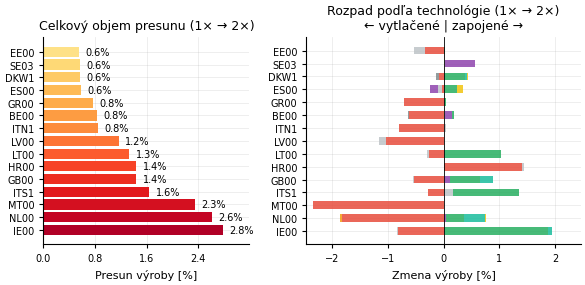

Saved /Users/radovanhodor/Documents/TUKE/Final diplomova praca/tukedip_pdflatex_utf-8/figures/fig_merit_order_pct_bat4.jpg


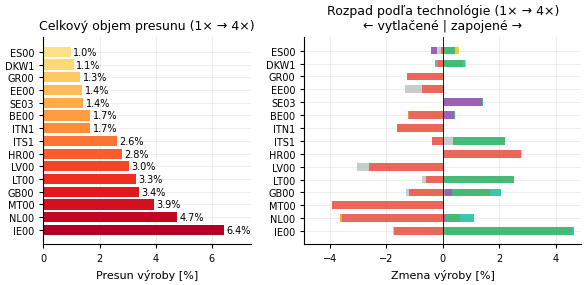

Saved /Users/radovanhodor/Documents/TUKE/Final diplomova praca/tukedip_pdflatex_utf-8/figures/fig_merit_order_pct_bat8.jpg


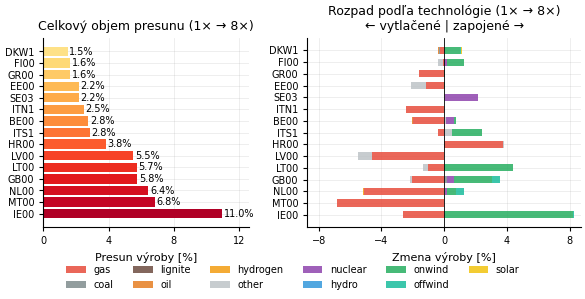

In [13]:
# Merit order displacement in % \u2014 three separate figures (one per bat_scale comparison)
gen_baseline = df_mo[df_mo.bat_scale == 1].groupby('zone')['twh'].sum()
comparisons_pct = [(1, 2), (1, 4), (1, 8)]

for bs_from, bs_to in comparisons_pct:
    piv = df_mo[df_mo.bat_scale.isin([bs_from, bs_to])].pivot_table(
        index=['zone', 'carrier'], columns='bat_scale', values='twh', fill_value=0)
    piv.columns = ['twh_from', 'twh_to']
    piv['delta'] = piv['twh_to'] - piv['twh_from']
    zone_disp = piv.groupby('zone')['delta'].apply(lambda x: x.abs().sum())
    zone_disp_pct = zone_disp / gen_baseline.reindex(zone_disp.index).clip(lower=0.01) * 100
    top_zones = zone_disp_pct.sort_values().tail(15).index[::-1]
    y_pos = np.arange(len(top_zones))
    zone_disp_sorted = zone_disp_pct.reindex(top_zones)

    fig, (ax_l, ax_r) = thesis_subplots('horizontal_2', nrows=1, ncols=2, figsize=(6.0, 3.0),
                                         gridspec_kw={'width_ratios': [3, 4]})

    # Left panel: total displacement
    colors_bar = plt.cm.YlOrRd(np.linspace(0.2, 0.9, len(top_zones)))[::-1]
    ax_l.barh(y_pos, zone_disp_sorted.values, color=colors_bar)
    ax_l.set_yticks(y_pos)
    ax_l.set_yticklabels(top_zones)
    ax_l.set_title(f'Celkový objem presunu ({SCALE_LABELS[bs_from]} \u2192 {SCALE_LABELS[bs_to]})')
    ax_l.grid(axis='x', alpha=0.3)
    xmax_l = max(zone_disp_sorted.values) * 1.15
    ax_l.set_xlim(0, xmax_l)
    ax_l.xaxis.set_major_locator(plt.MaxNLocator(4))
    for ii, v in enumerate(zone_disp_sorted.values):
        ax_l.text(v + 0.1, ii, f'{v:.1f}%', va='center', fontsize=7)
    ax_l.set_xlabel('Presun výroby [%]')

    # Right panel: carrier breakdown
    ax_r = fig.axes[1]
    delta_matrix = np.zeros((len(top_zones), len(all_carriers)))
    for j, carrier in enumerate(all_carriers):
        for ii, z in enumerate(top_zones):
            try:
                val_twh = piv.loc[(z, carrier), 'delta']
                base = gen_baseline.get(z, 0.01)
                delta_matrix[ii, j] = val_twh / base * 100
            except KeyError:
                delta_matrix[ii, j] = 0

    neg_left = np.zeros(len(top_zones))
    pos_left = np.zeros(len(top_zones))
    for j, carrier in enumerate(all_carriers):
        vals = delta_matrix[:, j]
        color = CARRIER_COLORS.get(carrier, '#bdc3c7')
        neg_part = np.where(vals < 0, vals, 0)
        pos_part = np.where(vals > 0, vals, 0)
        ax_r.barh(y_pos, neg_part, 0.6, left=neg_left, color=color, alpha=0.85, label=carrier)
        ax_r.barh(y_pos, pos_part, 0.6, left=pos_left, color=color, alpha=0.85)
        neg_left += neg_part
        pos_left += pos_part

    ax_r.set_yticks(y_pos)
    ax_r.set_yticklabels(top_zones)
    ax_r.axvline(0, color='black', linewidth=0.6)
    ax_r.set_title(f'Rozpad podľa technológie ({SCALE_LABELS[bs_from]} \u2192 {SCALE_LABELS[bs_to]})\n\u2190 vytlačené | zapojené \u2192')
    ax_r.grid(axis='x', alpha=0.3)
    xabs = max(abs(neg_left.min()), abs(pos_left.max())) * 1.05
    ax_r.set_xlim(-xabs, xabs)
    ax_r.xaxis.set_major_locator(plt.MaxNLocator(5))
    ax_r.set_xlabel('Zmena výroby [%]')

    # Legend at bottom (only on last figure)
    if bs_to == 8:
        handles, labels_l = ax_r.get_legend_handles_labels()
        fig.legend(handles, labels_l,
                   loc='lower center', ncol=(len(all_carriers) + 1) // 2,
                   bbox_to_anchor=(0.5, -0.02), frameon=False)
        plt.tight_layout()
        fig.subplots_adjust(bottom=0.22)
    else:
        plt.tight_layout()

    save_fig(fig, f'merit_order_pct_bat{bs_to}')
    plt.show()


### Net import change → `fig_import_change_pct_bat{2,4,8}`

Aggregate net import per zone across all scenarios, decomposed by neighbor.


In [11]:
# Build imp_avg and link_info base data for the import_change figures and DKE1 analysis below.
import re

links_file = PREPROCESSED / "links_p0.parquet"
static_links = pd.read_parquet(PREPROCESSED / "static_links.parquet")

link_info = {lid: (row["bus0"], row["bus1"]) for lid, row in static_links.iterrows()}

all_tags = res_vol["tag"].tolist()
link_cols = None
import_records = []

for idx, tag in enumerate(all_tags):
    if (idx+1) % 50 == 0: print(f"  {idx+1}/{len(all_tags)}...")
    lp = pd.read_parquet(links_file, filters=[("tag", "==", tag)])
    if link_cols is None:
        link_cols = [c for c in lp.columns if c not in ["tag", "timestamp"]]
    meta = res_vol[res_vol.tag == tag].iloc[0]
    bs = meta["bat_scale"]

    for zone in bus_cols_lmp:
        for lc in link_cols:
            if lc not in link_info: continue
            b0, b1 = link_info[lc]
            if b0 == zone:
                neighbor = b1; imp_twh = -lp[lc].sum() / 1e6
            elif b1 == zone:
                neighbor = b0; imp_twh = lp[lc].sum() / 1e6
            else:
                continue
            import_records.append({"tag": tag, "bat_scale": bs, "zone": zone,
                                   "neighbor": neighbor, "import_twh": imp_twh})
    del lp

imp_df = pd.DataFrame(import_records)
imp_per_tag = imp_df.groupby(["tag", "bat_scale", "zone", "neighbor"])["import_twh"].sum().reset_index()
imp_avg = imp_per_tag.groupby(["bat_scale", "zone", "neighbor"])["import_twh"].mean().reset_index()

print(f"Done. imp_avg rows: {len(imp_avg)}")


  50/432...
  100/432...
  150/432...
  200/432...
  250/432...
  300/432...
  350/432...
  400/432...
Done. imp_avg rows: 844


Top 10 zones by % import change: ['GR00', 'NL00', 'ITCA', 'BG00', 'IE00', 'DE00', 'GBNI', 'HR00', 'FR00', 'ITCS']
Saved /Users/radovanhodor/Documents/TUKE/Final diplomova praca/tukedip_pdflatex_utf-8/figures/fig_import_change_pct_bat2.jpg


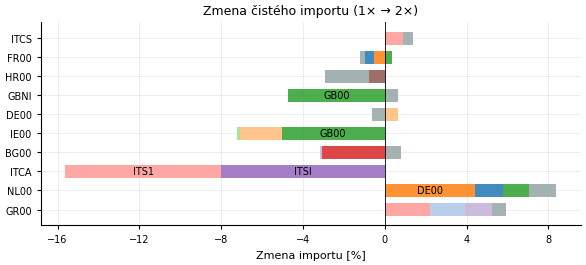

Saved /Users/radovanhodor/Documents/TUKE/Final diplomova praca/tukedip_pdflatex_utf-8/figures/fig_import_change_pct_bat4.jpg


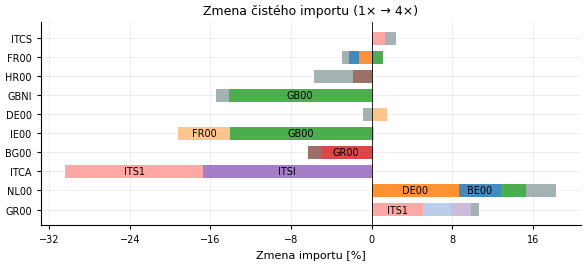

Saved /Users/radovanhodor/Documents/TUKE/Final diplomova praca/tukedip_pdflatex_utf-8/figures/fig_import_change_pct_bat8.jpg


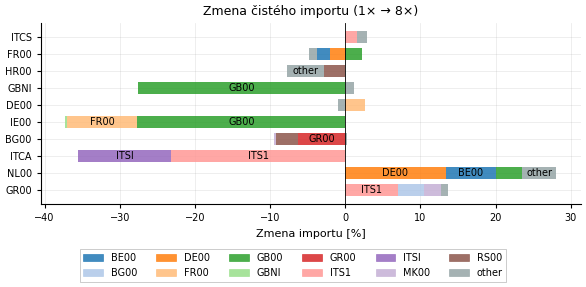

In [16]:
# Net import change per zone — three separate figures (one per bat_scale comparison)
imp1_all = imp_avg[imp_avg.bat_scale == 1].groupby('zone')['import_twh'].sum()
imp8_all = imp_avg[imp_avg.bat_scale == 8].groupby('zone')['import_twh'].sum()
net_change_pct = ((imp8_all - imp1_all) / imp1_all.abs().clip(lower=0.01) * 100).abs()
top10_pct = net_change_pct.sort_values(ascending=False).head(10).index.tolist()
print(f'Top 10 zones by % import change: {top10_pct}')

comparisons_imp_pct = [(1, 2), (1, 4), (1, 8)]

# First pass: count how often each neighbor appears in top3 across all comparisons/zones
from collections import Counter
neighbor_counts = Counter()
delta_cache = {}
for bs_from, bs_to in comparisons_imp_pct:
    imp_from = imp_avg[imp_avg.bat_scale == bs_from].set_index(['zone', 'neighbor'])['import_twh']
    imp_to = imp_avg[imp_avg.bat_scale == bs_to].set_index(['zone', 'neighbor'])['import_twh']
    total_imp_from = imp_from.groupby('zone').apply(lambda x: x.abs().sum())
    delta_twh = (imp_to - imp_from).reset_index()
    delta_twh.columns = ['zone', 'neighbor', 'delta_twh']
    delta_twh['delta_pct'] = delta_twh.apply(
        lambda r: r['delta_twh'] / max(total_imp_from.get(r['zone'], 0.01), 0.01) * 100, axis=1)
    delta_cache[(bs_from, bs_to)] = delta_twh
    for zone in top10_pct:
        zd = delta_twh[delta_twh.zone == zone].copy()
        zd['abs_delta'] = zd['delta_pct'].abs()
        zd = zd.sort_values('abs_delta', ascending=False)
        for n in zd.head(3)['neighbor'].tolist():
            neighbor_counts[n] += 1

# Keep top 11 most common neighbors; rest → 'other' (total 12 entries in legend)
LEGEND_LIMIT = 11
top_neighbors = [n for n, _ in neighbor_counts.most_common(LEGEND_LIMIT)]
all_neighbors = set(top_neighbors)

# Build consistent color map: one color per neighbor zone
palette = plt.cm.tab20.colors
neighbor_map = {n: palette[i % 20] for i, n in enumerate(sorted(all_neighbors))}
other_color = '#95a5a6'

import matplotlib.patches as mpatches

for bs_from, bs_to in comparisons_imp_pct:
    delta_twh = delta_cache[(bs_from, bs_to)]

    fig, ax = thesis_subplots('single_tall', figsize=(6.0, 2.8))
    y_positions = np.arange(len(top10_pct))

    for yi, zone in enumerate(top10_pct):
        zd = delta_twh[delta_twh.zone == zone].copy()
        zd['abs_delta'] = zd['delta_pct'].abs()
        zd = zd.sort_values('abs_delta', ascending=False)
        top3 = list(zd.head(3)[['neighbor', 'delta_pct']].values)
        # Fold any top3 neighbor that is not in the legend list into 'other'
        kept = []
        other_val = zd.iloc[3:]['delta_pct'].sum() if len(zd) > 3 else 0
        for n, v in top3:
            if n in all_neighbors:
                kept.append((n, v))
            else:
                other_val += v
        parts = kept + [('other', other_val)]

        left_neg = 0
        left_pos = 0
        for neighbor, val in parts:
            color = other_color if neighbor == 'other' else neighbor_map.get(neighbor, other_color)
            if val >= 0:
                ax.barh(yi, val, left=left_pos, color=color, alpha=0.85, height=0.7)
                if abs(val) > 4:
                    ax.text(left_pos + val/2, yi, neighbor, ha='center', va='center',
                            fontsize=7, color='black')
                left_pos += val
            else:
                ax.barh(yi, val, left=left_neg, color=color, alpha=0.85, height=0.7)
                if abs(val) > 4:
                    ax.text(left_neg + val/2, yi, neighbor, ha='center', va='center',
                            fontsize=7, color='black')
                left_neg += val

    ax.set_yticks(y_positions)
    ax.set_yticklabels(top10_pct)
    ax.axvline(0, color='black', linewidth=0.6)
    ax.set_title(f'Zmena čistého importu ({SCALE_LABELS[bs_from]} → {SCALE_LABELS[bs_to]})')
    ax.grid(axis='x', alpha=0.3)
    ax.xaxis.set_major_locator(plt.MaxNLocator(8))
    ax.set_xlabel('Zmena importu [%]')

    # Legend only under the last figure (bat8x)
    if bs_to == 8:
        legend_labels = sorted(all_neighbors) + ['other']
        patches = [mpatches.Patch(color=(other_color if n == 'other' else neighbor_map[n]),
                                  alpha=0.85, label=n) for n in legend_labels]
        fig.legend(handles=patches, loc='lower center',
                   ncol=min(len(legend_labels), 6),
                   bbox_to_anchor=(0.5, -0.05), frameon=True, framealpha=0.9)
        plt.tight_layout(rect=[0, 0.08, 1, 1])
    else:
        plt.tight_layout()

    save_fig(fig, f'import_change_pct_bat{bs_to}')
    plt.show()


### Price correlation → `fig_price_correlation`

LMP correlation heatmaps across 9 key zones at `bat1×`, `bat4×`, `bat8×`.


Saved /Users/radovanhodor/Documents/TUKE/Final diplomova praca/tukedip_pdflatex_utf-8/figures/fig_price_correlation.jpg


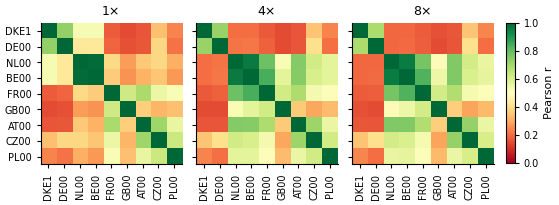


Key correlations:
  DKE1-DE00: 1×=0.73  4×=0.72  8×=0.69
  NL00-DE00: 1×=0.43  4×=0.21  8×=0.19
  BE00-NL00: 1×=0.99  4×=0.96  8×=0.96
  FR00-DE00: 1×=0.19  4×=0.18  8×=0.18
  GB00-FR00: 1×=0.62  4×=0.62  8×=0.61


In [16]:
# Price spillover: LMP correlation heatmaps across zones
zones_show = ['DKE1', 'DE00', 'NL00', 'BE00', 'FR00', 'GB00', 'AT00', 'CZ00', 'PL00']
bat_levels = [1, 4, 8]

corr_matrices = {}
for bs in bat_levels:
    tags_bs = res_vol[res_vol.bat_scale == bs]['tag'].tolist()[:20]
    corr_sum = np.zeros((len(zones_show), len(zones_show)))
    n = 0
    for tag in tags_bs:
        sub = lmp_raw[lmp_raw.tag == tag][zones_show].values
        if sub.shape[0] > 0:
            corr_sum += np.corrcoef(sub.T)
            n += 1
    corr_matrices[bs] = corr_sum / max(n, 1)

fig, axes = thesis_subplots('horizontal_3', nrows=1, ncols=3)

for ax, bs in zip(axes, bat_levels):
    im = ax.imshow(corr_matrices[bs], vmin=0.0, vmax=1.0, cmap='RdYlGn', aspect='equal')
    ax.set_xticks(range(len(zones_show)))
    ax.set_yticks(range(len(zones_show)))
    ax.set_xticklabels(zones_show, rotation=90)
    if ax is axes[0]:
        ax.set_yticklabels(zones_show)
    else:
        ax.set_yticklabels([])
    ax.set_title(SCALE_LABELS[bs])
    ax.grid(False)

fig.subplots_adjust(right=0.88, wspace=0.1)
cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
cb = fig.colorbar(im, cax=cbar_ax)
cb.set_label('Pearson r')

save_fig(fig, 'price_correlation')
plt.show()

print('\nKey correlations:')
pairs = [('DKE1','DE00'), ('DKW1','DE00'), ('NL00','DE00'), ('BE00','NL00'), ('FR00','DE00'), ('GB00','FR00')]
for z1, z2 in pairs:
    if z1 in zones_show and z2 in zones_show:
        i1, i2 = zones_show.index(z1), zones_show.index(z2)
        vals = [f'{SCALE_LABELS[bs]}={corr_matrices[bs][i1,i2]:.2f}' for bs in bat_levels]
        print(f'  {z1}-{z2}: {"  ".join(vals)}')


### DKE1 spillover evidence

DKE1 has a large CV reduction but minimal local generation/import changes (both ~0.4%). This supports the price-spillover interpretation in the thesis.


In [17]:
# DKE1 merit order displacement — aggregate % (supports thesis claim of ~0.4%)
ZONE = "DKE1"
gen_base_zone = df_mo[df_mo.bat_scale == 1].groupby("zone")["twh"].sum()

for bs_from, bs_to in [(1, 2), (1, 4), (1, 8)]:
    piv = (df_mo[df_mo.bat_scale.isin([bs_from, bs_to]) & (df_mo.zone == ZONE)]
           .pivot_table(index="carrier", columns="bat_scale", values="twh", fill_value=0))
    if piv.empty:
        print(f"{ZONE}: no data for bat{bs_from} vs bat{bs_to}"); continue
    piv.columns = ["twh_from", "twh_to"]
    total_abs_delta = (piv["twh_to"] - piv["twh_from"]).abs().sum()
    base = gen_base_zone.get(ZONE, 0.01)
    pct = total_abs_delta / base * 100
    print(f"{ZONE}: bat{bs_from}x -> bat{bs_to}x  merit order displacement = {pct:.2f}%")


DKE1: bat1x -> bat2x  merit order displacement = 0.19%
DKE1: bat1x -> bat4x  merit order displacement = 0.34%
DKE1: bat1x -> bat8x  merit order displacement = 0.45%


In [18]:
# DKE1 net import change — aggregate % (supports thesis claim of ~0.4%)
ZONE = "DKE1"

for bs_from, bs_to in [(1, 2), (1, 4), (1, 8)]:
    imp_from = (imp_avg[(imp_avg.bat_scale == bs_from) & (imp_avg.zone == ZONE)]
                .set_index("neighbor")["import_twh"])
    imp_to = (imp_avg[(imp_avg.bat_scale == bs_to) & (imp_avg.zone == ZONE)]
              .set_index("neighbor")["import_twh"])
    total_base = imp_from.abs().sum()
    total_delta = (imp_to - imp_from).abs().sum()
    pct = total_delta / max(total_base, 0.01) * 100
    print(f"{ZONE}: bat{bs_from}x -> bat{bs_to}x  net import change = {pct:.2f}%")


DKE1: bat1x -> bat2x  net import change = 0.95%
DKE1: bat1x -> bat4x  net import change = 1.81%
DKE1: bat1x -> bat8x  net import change = 2.74%


### Price spillover statistics → table `t:spillover`

Mean μ and std σ of hourly LMP at `bat1×` vs `bat8×`, averaged across 432 scenarios. DKE1 shows a large σ drop despite no local battery action — driven by DE00 price spillover through high LMP correlation.


In [19]:
# DKE1 μ, σ, CV (avg over 432 scenarios) — for table t:spillover
ZONE_DC = "DKE1"

tags1 = res_vol[res_vol.bat_scale == 1]["tag"].tolist()
tags8 = res_vol[res_vol.bat_scale == 8]["tag"].tolist()

def _zone_stats(tags, zone):
    rows = []
    for tag in tags:
        vals = lmp_raw[lmp_raw.tag == tag][zone].values
        if len(vals):
            rows.append((vals.mean(), vals.std(), vals.std()/vals.mean()))
    m = np.mean([r[0] for r in rows])
    s = np.mean([r[1] for r in rows])
    c = np.mean([r[2] for r in rows])
    return m, s, c, len(rows)

mean1, std1, cv1, n1 = _zone_stats(tags1, ZONE_DC)
mean8, std8, cv8, n8 = _zone_stats(tags8, ZONE_DC)

print(f"{ZONE_DC}  (no local battery)")
print(f"  bat1x (n={n1}): mean={mean1:.1f}, std={std1:.1f}, CV={cv1:.3f}")
print(f"  bat8x (n={n8}): mean={mean8:.1f}, std={std8:.1f}, CV={cv8:.3f}")
print(f"  delta mean: {mean8-mean1:+.1f} ({(mean8-mean1)/mean1*100:+.1f}%)")
print(f"  delta std:  {std8-std1:+.1f} ({(std8-std1)/std1*100:+.1f}%)")
print(f"  CV change:  {(cv8-cv1)/cv1*100:+.1f}%")


DKE1  (no local battery)
  bat1x (n=108): mean=41.6, std=116.1, CV=2.845
  bat8x (n=108): mean=38.4, std=64.8, CV=1.591
  delta mean: -3.1 (-7.6%)
  delta std:  -51.3 (-44.2%)
  CV change:  -44.1%


In [20]:
# DE00 μ, σ, CV (avg over 432 scenarios) — for table t:spillover (companion to DKE1 above)
ZONE_DE = "DE00"

mean1, std1, cv1, n1 = _zone_stats(tags1, ZONE_DE)
mean8, std8, cv8, n8 = _zone_stats(tags8, ZONE_DE)

print(f"{ZONE_DE}  (bat_scale varies uniformly across all zones)")
print(f"  bat1x (n={n1}): mean={mean1:.1f}, std={std1:.1f}, CV={cv1:.3f}")
print(f"  bat8x (n={n8}): mean={mean8:.1f}, std={std8:.1f}, CV={cv8:.3f}")
print(f"  delta mean: {mean8-mean1:+.1f} ({(mean8-mean1)/mean1*100:+.1f}%)")
print(f"  delta std:  {std8-std1:+.1f} ({(std8-std1)/std1*100:+.1f}%)")
print(f"  CV change:  {(cv8-cv1)/cv1*100:+.1f}%")


DE00  (bat_scale varies uniformly across all zones)
  bat1x (n=108): mean=72.6, std=170.9, CV=2.328
  bat8x (n=108): mean=67.3, std=109.5, CV=1.587
  delta mean: -5.3 (-7.3%)
  delta std:  -61.4 (-35.9%)
  CV change:  -31.8%


### DKE1–DE00 spike correlation (thesis: r = 0.73)

Pearson correlation of spike reductions in the top 50 most expensive hours of a CY2012 scenario.


In [21]:
# DKE1 vs DE00 spike correlation (thesis line: "correlation 0.73")
ZONE_SP = "DKE1"

# Use one representative CY2012 scenario (gas=22.68, co2=113.4, dur=1)
tag1 = res_vol[(res_vol.bat_scale==1) & (res_vol.bat_duration==1) &
               (res_vol.gas_price==22.68) & (res_vol.co2_price==113.4) &
               (res_vol.climate_year==2012)]["tag"].values[0]
tag8 = res_vol[(res_vol.bat_scale==8) & (res_vol.bat_duration==1) &
               (res_vol.gas_price==22.68) & (res_vol.co2_price==113.4) &
               (res_vol.climate_year==2012)]["tag"].values[0]

lmp1_all = lmp_raw[lmp_raw.tag == tag1].set_index("timestamp")[[ZONE_SP, "DE00"]]
lmp8_all = lmp_raw[lmp_raw.tag == tag8].set_index("timestamp")[[ZONE_SP, "DE00"]]

top_hours = lmp1_all[ZONE_SP].nlargest(50).index
de_top = lmp1_all["DE00"].nlargest(50).index
overlap = len(set(top_hours) & set(de_top))

spike_red = [lmp8_all.loc[ts, ZONE_SP] - lmp1_all.loc[ts, ZONE_SP] for ts in top_hours]
de_spike_red = [lmp8_all.loc[ts, "DE00"]   - lmp1_all.loc[ts, "DE00"]   for ts in top_hours]

from scipy.stats import pearsonr
r, p = pearsonr(de_spike_red, spike_red)

print(f"Top 50 spike hours overlap {ZONE_SP} vs DE00: {overlap}/50 ({overlap/50*100:.0f}%)")
print(f"Correlation of spike reduction ({ZONE_SP} vs DE00): r = {r:.2f} (p = {p:.2e})")


Top 50 spike hours overlap DKE1 vs DE00: 30/50 (60%)
Correlation of spike reduction (DKE1 vs DE00): r = 0.58 (p = 1.08e-05)


### EU demand-weighted CV vs bat_scale → `fig_eu_cv_vs_batscale`

EU aggregate CV by `bat_scale`, one line per climate year — shows saturation of the volatility-reduction effect.


In [22]:
# EU demand-weighted CV — data computation
import pypsa

_net = pypsa.Network(str(list(SOLVED_DIR.glob('bat1x_gas22.68_co2_113.4_cy2009_dur1x.nc'))[0]))
demand_per_zone = {}
for load_id, load in _net.loads.iterrows():
    bus = load['bus']
    avg_mw = _net.loads_t.p_set[load_id].mean() if load_id in _net.loads_t.p_set.columns else 0
    demand_per_zone[bus] = demand_per_zone.get(bus, 0) + avg_mw
del _net
weights = pd.Series(demand_per_zone)
weights = weights.reindex(bus_cols_lmp).fillna(0)
weights = weights / weights.sum()

cv_records = []
for _, row in res_vol.iterrows():
    tag = row['tag']
    lmp_tag = lmp_raw[lmp_raw.tag == tag][bus_cols_lmp]
    cv_zones = lmp_tag.std() / lmp_tag.mean()
    weighted_cv = (cv_zones * weights).sum()
    cv_records.append({'bat_scale': row['bat_scale'], 'bat_duration': row['bat_duration'],
                       'gas_price': row['gas_price'], 'co2_price': row['co2_price'],
                       'climate_year': row['climate_year'], 'cv': weighted_cv})
cv_df = pd.DataFrame(cv_records)
print(f'Computed CV for {len(cv_df)} scenarios')

cv_by_bs_cy = cv_df.groupby(['bat_scale', 'climate_year'])['cv'].mean().reset_index()
print('Data ready.')

INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'TYNDP2024_Electricity_2030' has buses, carriers, generators, links, loads, storage_units, sub_networks


Computed CV for 432 scenarios
Data ready.


Saved /Users/radovanhodor/Documents/TUKE/Final diplomova praca/tukedip_pdflatex_utf-8/figures/fig_eu_cv_vs_batscale.jpg


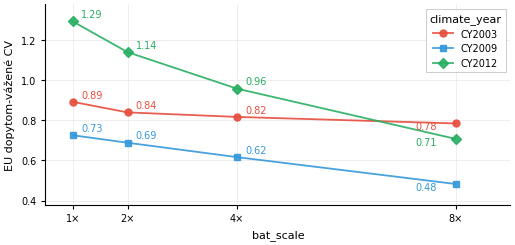


CV reduction per step:
  CY2003: bat1=0.893, bat2=0.840 (-5.9%), bat4=0.818 (-8.4%), bat8=0.785 (-12.1%)
  CY2009: bat1=0.726, bat2=0.689 (-5.2%), bat4=0.617 (-15.1%), bat8=0.482 (-33.6%)
  CY2012: bat1=1.295, bat2=1.141 (-11.8%), bat4=0.959 (-25.9%), bat8=0.708 (-45.3%)


In [23]:
fig, ax = thesis_subplots('single_short')

cy_colors = {2003: '#e74c3c', 2009: '#3498db', 2012: '#27ae60'}
cy_markers = {2003: 'o', 2009: 's', 2012: 'D'}

for cy in [2003, 2009, 2012]:
    sub = cv_by_bs_cy[cv_by_bs_cy.climate_year == cy]
    ax.plot(sub['bat_scale'], sub['cv'], '-',
            color=cy_colors[cy], marker=cy_markers[cy],
            markersize=5, linewidth=1.3,
            label=CY_LABELS[cy], alpha=0.9)
    for _, r in sub.iterrows():
        xoff = -0.35 if r['bat_scale'] == 8 else 0.15
        yoff = -0.03 if r['bat_scale'] == 8 else 0.02
        ha = 'right' if r['bat_scale'] == 8 else 'left'
        ax.text(r['bat_scale'] + xoff, r['cv'] + yoff, f'{r["cv"]:.2f}',
                color=cy_colors[cy], ha=ha, fontsize=7)

ax.set_xlabel('bat_scale')
ax.set_ylabel('EU dopytom-vážené CV')
ax.set_xticks([1, 2, 4, 8])
ax.set_xticklabels([SCALE_LABELS[bs] for bs in [1, 2, 4, 8]])
ax.set_xlim(0.5, 9)
ax.legend(title='climate_year')
ax.grid(alpha=0.3)
ax.set_ylim(0.38, 1.38)

save_fig(fig, 'eu_cv_vs_batscale')
plt.show()

# Print reductions
print('\nCV reduction per step:')
for cy in [2003, 2009, 2012]:
    sub = cv_by_bs_cy[cv_by_bs_cy.climate_year == cy].set_index('bat_scale')['cv']
    print(f'  CY{cy}: bat1={sub[1]:.3f}, bat2={sub[2]:.3f} ({(sub[2]-sub[1])/sub[1]*100:+.1f}%), '
          f'bat4={sub[4]:.3f} ({(sub[4]-sub[1])/sub[1]*100:+.1f}%), '
          f'bat8={sub[8]:.3f} ({(sub[8]-sub[1])/sub[1]*100:+.1f}%)')
